In [1]:
import pandas as pd
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'  # default is 'last'

<div class="jumbotron">
    <h1 class="display-3">Navigating the Data Deluge</h1>
    <h2 class="display-4">Dimensionality Reduction for Business Decisions</h2>
    <hr class="my-4">
    <p>Instructor: Dr. Yan Li</p>
</div>

## The Business Logic of Reduction

<div class="alert alert-info">
    <strong>The Problem:</strong> Modern businesses collect thousands of data points per customer. A hotel manager cannot look at 100 features for every guest.
</div>

Our journey today follows three logical steps:

1.  **Row Reduction (Aggregation):** "The Executive Summary" — Turning millions of transactions into monthly trends.
2.  **PCA (Principal Components):** "Finding the Pulse" — Identifying the 3-5 core drivers that explain 80% of business variation.
3.  **Non-linear Mapping (t-SNE/UMAP):** "The Customer Landscape" — Visualizing complex segments to see who our customers really are.

<center><img src="./img/dimreduction/reduction_logic.png" width="50%"></center>

## Data Reduction: Two Strategies

Data reduction shrinks dataset size while preserving analytical value. Two fundamentally different approaches:

| Strategy | What It Does | Methods in This Course |
|:---|:---|:---|
| **Row Reduction** | Reduce number of records (rows) | Aggregation, GroupBy, `agg()`, `apply()` |
| **Feature Reduction** | Reduce number of attributes (columns) | PCA, t-SNE, UMAP |

We start with **row reduction**, then move to **feature reduction**.

### Row Reduction: Turning Noise into Trends

<div class="alert alert-success">
    Think of aggregation as "Zooming Out." You lose the individual pixel detail but gain a clear picture of the landscape.
</div>

#### Grouping Operations

- Aggregation is essentially a grouping operation on data

- Grouping mechanism: Split-Apply-Combine

<center><img src="./img/pandas/groupby.png" width=60%></center>

#### The `groupby` Function

```python
DataFrame.groupby(by=None, axis=0, sort=True)
```
+ `by`: Grouping criteria
    * `label` or `list of labels`: Column name(s)
    * `dict`: Dictionary values as grouping keys
+ `sort`: Sort group keys. Setting `sort=False` improves performance.

In [2]:
df = pd.DataFrame({'key1' : ['a', 'a', 'b', 'b', 'a'], 'key2' : ['one', 'two', 'one', 'two', 'one'], 'data1' : np.random.randn(5), 'data2' : np.random.randn(5)})
df
gp = df.groupby(by='key2')
gp

,key1,key2,data1,data2
0,a,one,2.624207,-0.647291
1,a,two,-0.765770,0.177688
2,b,one,-1.654551,0.613052
3,b,two,-0.054388,-1.060456
4,a,one,-0.183383,0.084033


- Apply the `size()` function to get the size of each group

In [5]:
df.groupby(by='key2').size()

key2
one    3
two    2
dtype: int64

#### Aggregate Computations

- Computing on grouped data

Function|Description
---|---
`count()`|Number of non-`NaN` values in each group
`sum()`|Sum of non-`NaN` values
`mean()`|Mean of non-`NaN` values
`median()`|Median of non-`NaN` values
`std()`, `var()`|Standard deviation and variance of non-`NaN` values
`min()`, `max()`|Min and max of non-`NaN` values
`prod()`|Product of non-`NaN` values
`first()`, `last()`|First or last non-`NaN` value

### The `agg` or `aggregate` Function

```python
DataFrame.agg(func, axis=0)
```
+ `func`:
    * A function or function name
    * A list of functions/function names — results labeled accordingly
    * A dict of `label: function/function name/list` — apply different functions to different columns

In [11]:
df.drop(columns='key2').groupby('key1').agg(['mean','std'])
# df.groupby('key1').agg({'data1': ['mean'], 'data2': ['std']})

data1               data2          
          mean       std      mean       std
key1                                        
a     0.558352  1.812626 -0.128523  0.451700
b    -0.854469  1.131486 -0.223702  1.183348

- Custom functions can be passed to `agg`

## From Row Reduction to Feature Reduction

We covered the first strategy. Now the second.

| ""| Row Reduction | Feature Reduction |
|:---|:---|:---|
| **What** | Aggregate rows into summary groups | Transform columns into fewer dimensions |
| **Methods** | `groupby()` + `agg()` / `apply()` | PCA, t-SNE, UMAP |
| **Effect** | Fewer rows (e.g., daily -> monthly) | Fewer columns (e.g., 50 features -> 5 components) |
| **Info preserved** | Summary stats, trends | Variance structure, relationships |
| **When to use** | Reporting, roll-ups, trend analysis | Visualization, denoising, ML preprocessing |

**Next**: Curse of Dimensionality and how PCA solves it.

## PCA: Finding the Core Pulse of Your Business
<hr>
Feature-based dimensionality reduction through orthogonal transformation

### The Curse of Dimensionality: Too Much Hay, Too Little Needle

**Imagine you are looking for a specific guest in a hotel:**
- **1D (a hallway):** Easy to find them in 10 rooms.
- **2D (a floor):** You need to check 100 rooms.
- **3D (the whole building):** 1,000 rooms.
- **100D (The Data Cloud):** More rooms than there are atoms in the universe!

<div class="alert alert-warning">
    <strong>Business Consequence:</strong> In high dimensions, every customer looks "far away" from everyone else. Patterns vanish into the void.
</div>

### What is PCA?

**PCA: Finding the Core Pulse of Your Business** is a linear dimensionality reduction technique that:
- Finds new axes (principal components) that capture **maximum variance** in data
- Components are **orthogonal** (uncorrelated) to each other
- First component captures most variance, second captures next most, etc.

**Geometric intuition**:
- Rotate coordinate system to align with data's natural spread
- Drop low-variance dimensions = minimal information loss

<center><img src="./img/dimreduction/GaussianScatterPCA.png" width="60%"></center>

*PCA finds the direction (red) of maximum variance, then orthogonal direction (green) of remaining variance.*

### PCA as Linear Combinations

A principal component is a **weighted sum (linear combination) of the original features**:

$$\text{PC}_1 = w_{11} x_1 + w_{12} x_2 + \cdots + w_{1d} x_d$$

$$\text{PC}_2 = w_{21} x_1 + w_{22} x_2 + \cdots + w_{2d} x_d$$

$$\vdots$$

$$\text{PC}_k = w_{k1} x_1 + w_{k2} x_2 + \cdots + w_{kd} x_d$$

The weights $w_{ij}$ are the **loadings**: loading $w_{ij}$ tells how much original feature $x_j$ contributes to component $\text{PC}_i$. PCA chooses the weights so that:

- Weights are **unit vectors**: $w_{i1}^2 + w_{i2}^2 + \cdots + w_{id}^2 = 1$. Scale-free, otherwise PC1 would just be the largest-magnitude feature.
- **PC1 maximizes variance**: $\text{Var}(\text{PC}_1) = \lambda_1$ is the largest possible among all unit-weight directions.
- **Components are orthogonal**: each later PC maximizes remaining variance among directions **uncorrelated with** (perpendicular to) all earlier ones.

### PCA: step-by-step

#### Step 1: Center the data
$$\mathbf{X}_{centered} = \mathbf{X} - \boldsymbol{\mu}$$
Subtract mean from each feature so data has zero mean.

#### Step 2: Compute covariance matrix
$$\mathbf{C} = \frac{1}{n-1} \mathbf{X}_{centered}^T \mathbf{X}_{centered}$$
$C_{ij}$ measures how feature $i$ co-varies with feature $j$.

#### Step 3: Eigendecomposition
$$\mathbf{C} \mathbf{v}_i = \lambda_i \mathbf{v}_i$$
- $\mathbf{v}_i$ = eigenvector = direction of a principal component
- $\lambda_i$ = eigenvalue = variance captured by that component

#### Step 4: Sort by eigenvalue (descending)
- $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_d$
- PC1 = direction of **maximum variance**

#### Step 5: Project data
$$\mathbf{Z} = \mathbf{X}_{centered} \mathbf{W}_k$$
- $\mathbf{W}_k$ = matrix of top $k$ eigenvectors
- $\mathbf{Z}$ = reduced representation ($n \times k$)

#### Explained Variance Ratio
$$\text{EV}_i = \frac{\lambda_i}{\sum_{j=1}^d \lambda_j}$$
Fraction of total variance captured by component $i$.

#### PCA Implementation

In [13]:
# --- PCA in Python: Concrete Example ---
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load hotel booking dataset (familiar from earlier labs)
df = pd.read_csv('data/analysis/hotel_bookings.csv')
print(f'Original shape: {df.shape}')

Original shape: (119390, 32)


In [14]:
# --- Select numeric features for PCA ---
# Drop ID columns and target (is_canceled) - we want to see structure without target
X = df.drop(columns=["hotel", "arrival_date_month", "meal", "country", "market_segment", "distribution_channel", "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type", "reservation_status", "reservation_status_date", "is_canceled"])

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Drop rows with any NaN
X = X.dropna()
print(f'Feature matrix shape (after cleaning): {X.shape}')
print(f'Feature names: {list(X.columns)}')

Feature matrix shape (after cleaning): (217, 19)
Feature names: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [15]:
# --- Standardize features (critical for PCA!) ---
# PCA is sensitive to scale: a feature in dollars dominates a feature in percentages
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# --- Fit PCA and analyze explained variance ---
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio per component
evr = pca.explained_variance_ratio_

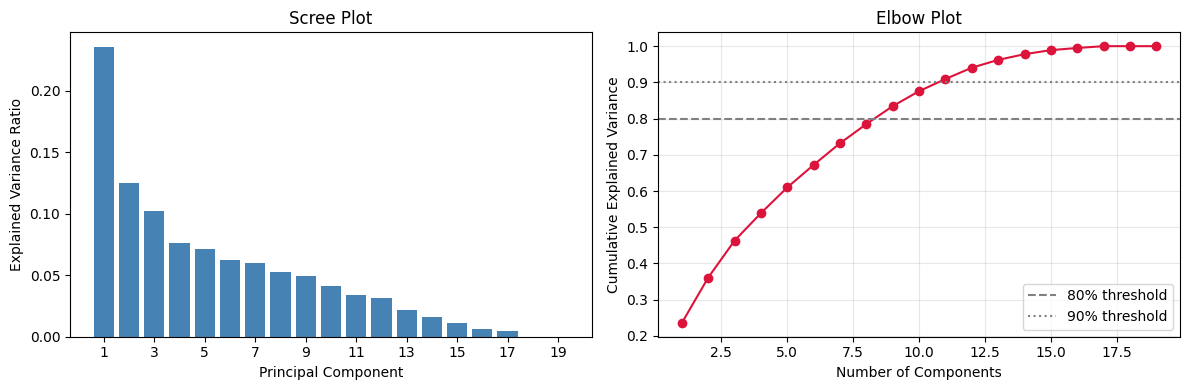

PC1 explains 23.6% of variance
First 3 PCs explain 46.3%
Components needed for 80%: 9


In [24]:
# --- Scree plot + Cumulative variance (elbow plot) ---
cumulative = np.cumsum(evr)

_ = plt.figure(figsize=(12, 4));

_ = plt.subplot(1, 2, 1);
_ = plt.bar(range(1, len(evr) + 1), evr, color='steelblue');
_ = plt.xlabel('Principal Component');
_ = plt.ylabel('Explained Variance Ratio');
_ = plt.title('Scree Plot');
_ = plt.xticks(range(1, len(evr) + 1, 2));

_ = plt.subplot(1, 2, 2);
_ = plt.plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='crimson');
_ = plt.axhline(y=0.8, color='gray', linestyle='--', label='80% threshold');
_ = plt.axhline(y=0.9, color='gray', linestyle=':', label='90% threshold');
_ = plt.xlabel('Number of Components');
_ = plt.ylabel('Cumulative Explained Variance');
_ = plt.title('Elbow Plot');
_ = plt.legend();
_ = plt.grid(True, alpha=0.3);
plt.tight_layout();
plt.show();

print(f'PC1 explains {evr[0]:.1%} of variance')
print(f'First 3 PCs explain {cumulative[2]:.1%}')
print(f'Components needed for 80%: {(cumulative < 0.8).sum() + 1}')

<Figure size 900x600 with 0 Axes>

Text(0.5, 0, 'PC1 (23.6%)')

Text(0, 0.5, 'PC2 (12.5%)')

Text(0.5, 1.0, 'PCA Projection of Hotel Bookings (color = cancellation status)')

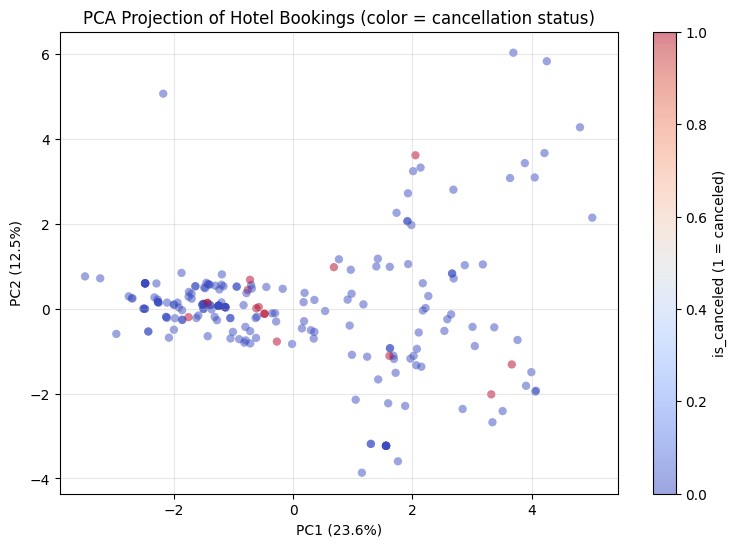

Interpretation: If canceled bookings cluster, PC1 + PC2 capture risk-relevant structure.
2 components explain 36.1% of total variance.


In [25]:
# --- Project data to 2D and visualize ---
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# Get target for color coding (using indices that remained after dropna)
valid_idx = X.index
target = df.loc[valid_idx, 'is_canceled']

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=target, cmap="coolwarm", alpha=0.5, edgecolors="none"
)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
plt.title('PCA Projection of Hotel Bookings (color = cancellation status)')
cbar = plt.colorbar(scatter)
cbar.set_label("is_canceled (1 = canceled)")
plt.grid(True, alpha=0.3)
plt.show();

print('Interpretation: If canceled bookings cluster, PC1 + PC2 capture risk-relevant structure.')
print(f'2 components explain {pca_2d.explained_variance_ratio_.sum():.1%} of total variance.')

In [31]:
# --- Interpret loadings (which features drive each PC?) ---
loadings = pd.DataFrame( pca.components_.T[:, :2],index=X.columns,columns=['PC1', 'PC2'])

In [27]:
# --- Top contributors to PC1 ---
pc1_top = loadings['PC1'].abs().sort_values(ascending=False)
print('Top 8 features driving PC1:')
for feat in pc1_top.head(8).index:
    print(f'  {feat:20s}  loading = {loadings.loc[feat, "PC1"]:+.4f}')

Top 8 features driving PC1:
  arrival_date_year     loading = +0.4018
  stays_in_week_nights  loading = -0.3585
  arrival_date_week_number  loading = -0.3481
  adr                   loading = +0.3281
  booking_changes       loading = -0.3176
  stays_in_weekend_nights  loading = -0.2659
  arrival_date_day_of_month  loading = +0.2586
  total_of_special_requests  loading = +0.2510


In [30]:
# --- Top contributors to PC2 ---
pc2_top = loadings['PC2'].abs().sort_values(ascending=False)
print('Top 8 features driving PC2:')
for feat in pc2_top.head(8).index:
    print(f'  {feat:20s}  loading = {loadings.loc[feat, "PC2"]:+.4f}')

Top 8 features driving PC2:
  is_repeated_guest     loading = +0.4468
  previous_bookings_not_canceled  loading = +0.4348
  lead_time             loading = -0.4243
  adults                loading = -0.3778
  agent                 loading = +0.3185
  adr                   loading = -0.3113
  arrival_date_week_number  loading = -0.2072
  previous_cancellations  loading = +0.1368


#### Interpreting PCA Results

Interpretation is built directly from the loadings printed in the cells above (hotel bookings data, standardized, 19 features).

##### PC1 — later-vintage arrivals & pricing

| Feature | PC1 loading | Direction of high PC1 score |
|:---|:---:|:---|
| `arrival_date_year` | +0.40 | Bookings in later years |
| `adr` | +0.33 | Higher daily rate |
| `arrival_date_day_of_month` | +0.26 | Later day in month |
| `total_of_special_requests` | +0.25 | More special requests |
| `stays_in_week_nights` | -0.36 | Shorter weekday stays |
| `arrival_date_week_number` | -0.35 | Bookings earlier in the calendar year |
| `booking_changes` | -0.32 | Fewer changes made to the booking |

**PC1 captures a time/value trade-off** — later dates with higher ADR and more requests on one side, longer early-year stays with more booking changes on the other.

##### PC2 — repeat-guest loyalty vs first-time lead time

| Feature | PC2 loading | Interpretation of high PC2 score |
|:---|:---:|:---|
| `is_repeated_guest` | +0.45 | Returning guests |
| `previous_bookings_not_canceled` | +0.43 | Past bookings kept |
| `lead_time` | -0.42 | Short lead time |
| `adults` | -0.38 | Smaller party size |
| `agent` | +0.32 | Booked via a travel agent |
| `adr` | -0.31 | Lower daily rate |

**PC2 is a loyalty/planning dimension** — positive side: returning guests with booking history who book late and via agents; negative side: first-time bookings made early with more guests.

####  Business decisions enabled:
- Use PC1-PC2 space for **visual customer segmentation** — PC1 sorts by time/value, PC2 by loyalty/planning, so the two axes cross two independent business stories. 
  - Example: a mid-PC1, high-PC2 guest is a loyal repeat visitor to target for retention; a high-PC1, low-PC2 one is a first-time high-ADR booking. Segment on both axes, not either alone.
- Feed top 8 PCs (covering 75%+ variance) into downstream models instead of 20+ raw features

In [ ]:
# --- Practical: PCA as preprocessing for modeling ---
# Reduce to 8 components (covers ~75%+ variance typically)
pca_final = PCA(n_components=8)
X_reduced = pca_final.fit_transform(X_scaled)

print(f'Original features: {X.shape[1]}')
print(f'Reduced features:  {X_reduced.shape[1]}')
print(f'Variance retained: {pca_final.explained_variance_ratio_.sum():.1%}')

print('\\nNow you can use X_reduced in clustering or classification!')

Original features: 19
Reduced features:  8
Variance retained: 78.5%
\nNow you can use X_reduced in clustering or classification!


### PCA: Summary

| Aspect | Summary |
|--------|---------|
| **What** | Linear transformation to uncorrelated components ordered by variance |
| **Why** | Reduce noise, avoid multicollinearity, enable visualization, speed up training |
| **When** | High-dimensional data with correlated features |
| **Preprocessing** | **Always standardize** (PCA is scale-sensitive) |
| **k selection** | Scree plot elbow, cumulative variance threshold (80-90%), or domain need |
| **Limitations** | Linear only, assumes Gaussian, components hard to interpret |

<div class="alert alert-info">
<strong>Rule of thumb</strong>: Start with PCA. If data is highly non-linear (e.g., text embeddings, image pixels), try t-SNE or UMAP next.
</div>

## t-SNE: Non-linear Dimensionality Reduction
<hr>
t-Distributed Stochastic Neighbor Embedding — preserving local structure in high-dimensional data

### Limitations of PCA: The Non-linear Challenge

PCA is **linear**: it assumes data lies on a flat plane. But real-world business data is often "curved."

1. **Curved Patterns (Customer Preferences):**
   - *Scenario*: As luxury level increases, willingness to pay doesn't just go up linearly. It might plateau for "premium" and then skyrocket for "ultra-luxury." This forms a **curve**, not a line.


2. **Manifold Structure (Text & Sentiment):**
   - *Scenario*: In review data, "Not good" and "Good" are far apart in sentiment, but "Not bad" and "Average" might be close on a curved path. A **manifold** is a high-dimensional surface that looks flat up close but is curved globally (like the surface of the Earth).

3. **Non-linear Subspaces (Image & Behavior):**
   - *Scenario*: A customer's behavior over time might cycle (weekly patterns). Projecting this with PCA just gives a messy blob. A non-linear method sees the **spiral** of their habits.

<div class="alert alert-warning">
    <strong>The Danger:</strong> PCA will "squash" these curves, forcing points that are distant on the curve to appear close together, creating false insights.
</div>

### How t-SNE Works: The "Social Network" Intuition

t-SNE doesn't just project points; it **reconstructs a social network** in 2D.

#### 1. High-D Friendships (Gaussian Similarity)
In high-D, we calculate the probability that point $i$ would pick point $j$ as its neighbor:
$$p_{j|i} \propto \exp\left(-\frac{\|\mathbf{x}_i - \mathbf{x}_j\|^2}{2\sigma_i^2}\right)$$
- **Close neighbors** = High probability ("Friends").
- **Distant points** = Near-zero probability ("Strangers").
- **Perplexity** is the **"Friendship Budget"** — the effective number of neighbors each point tries to account for.

#### 2. Low-D Mapping (t-Distribution)
We place points in 2D and measure their similarity using a **t-distribution**:
$$q_{ij} \propto (1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}$$
- **Why t-distribution?** It has "fatter tails" than a normal distribution.
- **The Crowding Problem**: In high-D, there's lots of "room." In 2D, points get squashed. The "fat tails" of the t-distribution act like a stronger repulsion force, pushing "Strangers" further away so clusters don't overlap.

#### 3. The Tug-of-War (Optimization)
t-SNE moves points in 2D until the 2D network ($Q$) matches the high-D network ($P$) as closely as possible.

**Key Parameters**:
- **Perplexity** (5-50):
    - **Low (< 20)**: Focuses on local neighbors (small, tight clusters).
    - **High (> 30)**: Focuses on global structure (larger, more spread out clusters).
- **Learning Rate**: How fast the "tug-of-war" moves points.

### t-SNE in Python

Using `sklearn.manifold.TSNE` with the same `hotel_bookings.csv` dataset from the PCA section.

In [1]:
# --- t-SNE on hotel booking data ---
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load and prepare same data as PCA (reuse scaled data if in memory)
# If running fresh:
df = pd.read_csv('data/analysis/hotel_bookings.csv')
X = df.drop(columns=["hotel", "arrival_date_month", "meal", "country", "market_segment", "distribution_channel", "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type", "reservation_status", "reservation_status_date", "is_canceled"])
X = X.select_dtypes(include=[np.number]).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# --- Fit t-SNE (2 components) ---
# Warning: t-SNE is O(n^2) - may take 30-60s on full dataset
# For demo speed, we sample 2000 rows
np.random.seed(42)
n_sample = min(2000, len(X_scaled))
idx = np.random.choice(len(X_scaled), n_sample, replace=False)
X_sample = X_scaled[idx]
target_sample = df.loc[X.index[idx], 'is_canceled']

```python
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
```
- `n_components=2`: Reduce to 2D for visualization. It can be higher for downstream ML tasks, but visualization is limited to 2D/3D.
- `perplexity`: Controls local vs global structure. The larger the perplexity, the more global structure is preserved.
- `learning_rate`: Step size for optimization

In [8]:
# --- Fit t-SNE with default perplexity=30 ---
tsne = TSNE(n_components=2, random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_sample)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 217 samples in 0.000s...
[t-SNE] Computed neighbors for 217 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 217 / 217
[t-SNE] Mean sigma: 1.380999
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.841679
[t-SNE] KL divergence after 1000 iterations: 0.220981


#### Understanding the Difference: PCA vs. t-SNE

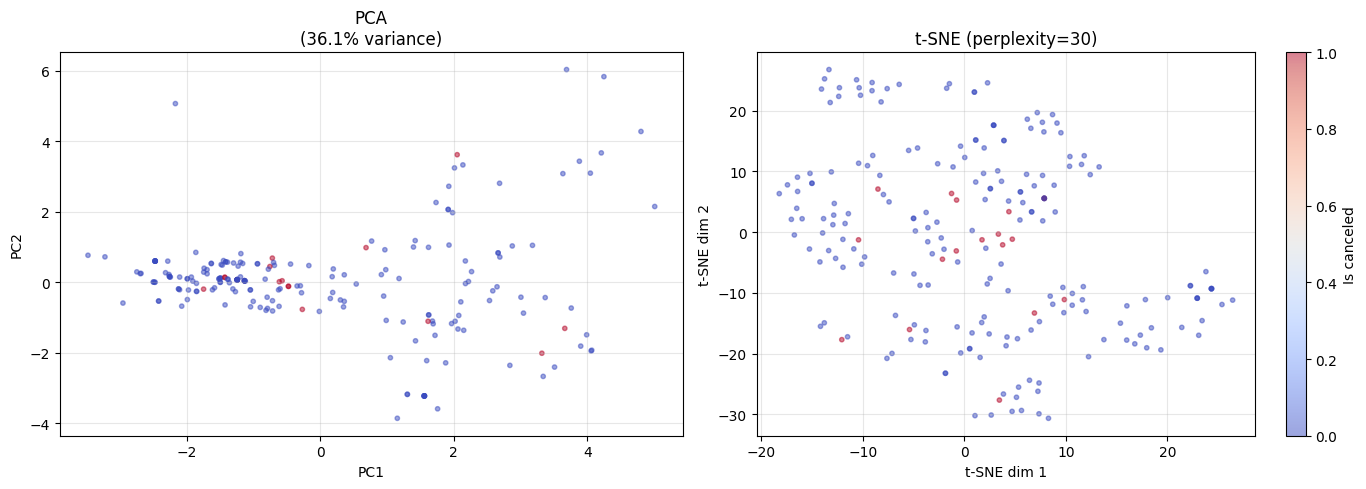

In [14]:
# --- Side-by-side: PCA vs t-SNE ---
# Compute PCA on same sample for fair comparison
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2)
X_pca_sample = pca_2d.fit_transform(X_sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PCA plot: Preserves global variance. Look for overall spread.
sc1 = ax1.scatter(
    X_pca_sample[:, 0], X_pca_sample[:, 1],
    c=target_sample, cmap="coolwarm", alpha=0.5, s=10
)
ax1.set_title(f"PCA\n({pca_2d.explained_variance_ratio_.sum():.1%} variance)")
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True, alpha=0.3)

# t-SNE plot: Preserves local neighborhoods. Look for tight "islands".
sc2 = ax2.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=target_sample, cmap="coolwarm", alpha=0.5, s=10
)
ax2.set_title("t-SNE (perplexity=30)")
ax2.set_xlabel('t-SNE dim 1')
ax2.set_ylabel('t-SNE dim 2')
ax2.grid(True, alpha=0.3)

# Shared colorbar for both subplots
# label='Is canceled' maps the target variable (1=Yes, 0=No) to the color scale
fig.colorbar(sc2, ax=ax2, label='Is canceled')
plt.tight_layout()
plt.show();

When you look at the side-by-side plots above, here is how to interpret them:

1. **The Shared Colorbar (`Is canceled`)**:
   - We use a shared colorbar to show that both plots are visualizing the **same data** and the **same outcome**.
   - **Red points** = Canceled bookings ($1$).
   - **Blue points** = Successful stays ($0$).

2. **PCA (The "Global Viewer")**:
   - PCA looks for the directions where the data varies the most.
   - If canceled and non-canceled bookings are mixed together, it means the "reason" they differ isn't a simple linear combination of features.

3. **t-SNE (The "Local Organizer")**:
   - t-SNE doesn't care about the total variance. It only cares about **who your neighbors are**.
   - If you see **isolated "islands" of red points**, it means t-SNE found specific, non-linear patterns (e.g., "last-minute bookings from a specific region with no deposit") that characterize cancellations.

**Key Takeaway**: If PCA shows a big soup but t-SNE shows distinct islands, your data has **non-linear clusters** that are invisible to linear methods.

#### Effects of Perplexity on t-SNE

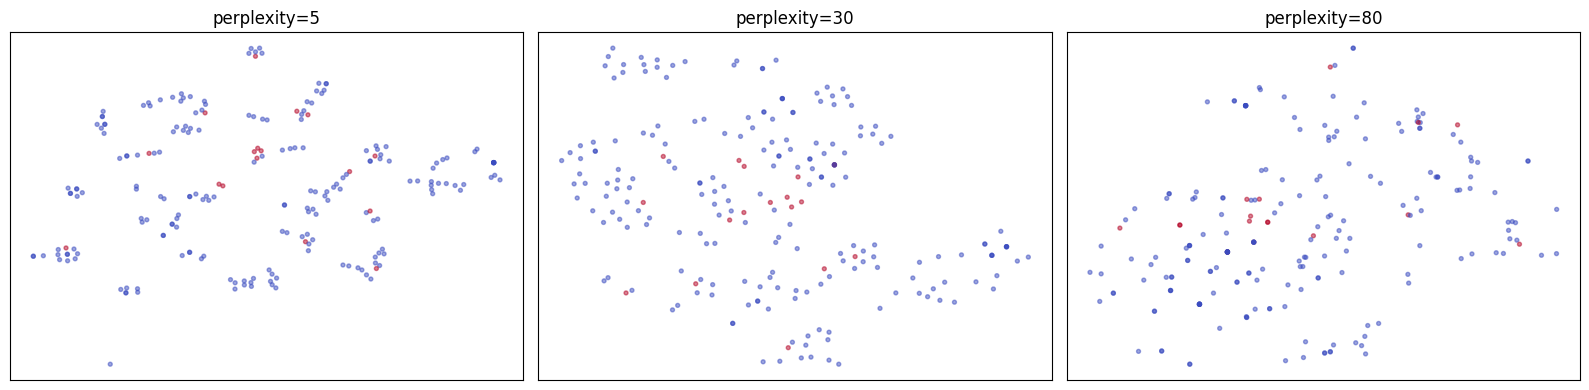

In [5]:
# --- Experiment: effect of perplexity ---
perplexities = [5, 30, 80]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_p = tsne_p.fit_transform(X_sample)
    ax.scatter(
        X_p[:, 0], X_p[:, 1],
        c=target_sample, cmap="coolwarm", alpha=0.5, s=8
    )
    ax.set_title(f"perplexity={perp}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show();

#### Practical tip: t-SNE for preprocessing (set high perplexity)
For dimensionality reduction to feed into clustering/classification:
- Use PCA first to reduce to dimensions (denoising)
- Then t-SNE on the PCA-reduced data
- High perplexity (~50) preserves more global structure

In [ ]:
pca_8 = PCA(n_components=8)
X_pca8 = pca_8.fit_transform(X_scaled)
print(f'PCA reduced {X_scaled.shape[1]} -> {X_pca8.shape[1]} dims')

PCA reduced 19 -> 8 dims


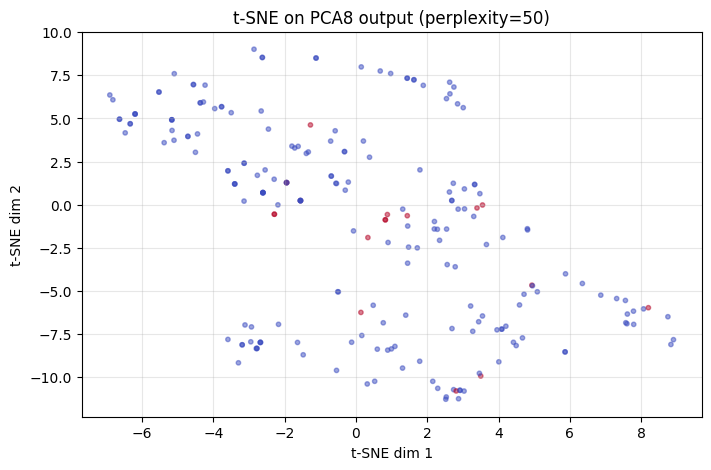

PCA + t-SNE pipeline: PCA denoises, t-SNE reveals local clusters.


In [17]:
# --- Fit t-SNE on PCA-preprocessed data ---
X_pca8_sample = X_pca8[idx]  # same sample

tsne_pipeline = TSNE(
    n_components=2, perplexity=50,
    random_state=42, verbose=0
)
X_tsne_pipe = tsne_pipeline.fit_transform(X_pca8_sample)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_tsne_pipe[:, 0], X_tsne_pipe[:, 1],
    c=target_sample, cmap="coolwarm", alpha=0.5, s=10
)
plt.title("t-SNE on PCA8 output (perplexity=50)")
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.grid(True, alpha=0.3)
plt.show()

print('PCA + t-SNE pipeline: PCA denoises, t-SNE reveals local clusters.')

### Interpreting t-SNE Plots: What to Look For

- DO:
  - Look for **clusters** — groups of points tightly packed
  - Compare **relative positions** — points near each other are similar
  - Check if known groups (e.g., canceled bookings) form coherent regions

- DON'T:
  - Don't interpret axis values (they have no meaning)
  - Don't compare cluster sizes across plots (t-SNE preserves local but not global density)
  - Don't trust distances between clusters (only distances within clusters are meaningful)

- Practical tips:
  - **Run multiple times** with different random seeds — consistent clusters are robust
  - **Start with perplexity=30** (default), adjust up (more global) or down (more local)
  - **If data has >50 features**, reduce with PCA first for speed and denoising
  - **Sample size** — t-SNE on >10K points becomes very slow; use `fit_transform` on a sample

## t-SNE: Key Takeaways

| Aspect | Summary |
|--------|---------|
| **What** | Non-linear dimensionality reduction preserving local neighborhoods |
| **Why** | PCA fails on non-linear manifolds; t-SNE reveals clusters PCA misses |
| **When** | Visualization, cluster discovery, exploring high-D structure |
| **Key param** | **perplexity** (5-50) — expected neighbors; tune for your data |
| **Pros** | Beautiful clusters, reveals non-linear patterns |
| **Cons** | Slow ($O(n^2)$), stochastic, axes uninterpretable, can't transform new data |
| **Pipeline** | PCA → t-SNE: PCA for denoising, t-SNE for visualization |

## UMAP: The High-Speed Map for Big Data
<hr>
Uniform Manifold Approximation and Projection — preserving both local AND global structure with higher speed

### Limitations of t-SNE

t-SNE is powerful but has drawbacks:

| Issue | Why It Matters |
|-------|----------------|
| **Slow on large data** | $O(n^2)$ complexity — painful above 10K points |
| **Stochastic** | Different runs give different plots |
| **No transform for new data** | Must re-run t-SNE on full dataset each time |
| **Global structure lost** | Cluster distances are meaningless |
| **Perplexity tuning** | Wrong perplexity = misleading clusters |

**UMAP** addresses all these issues while producing comparable or better visualizations.

| UMAP Advantage | Detail |
|----------------|--------|
| **Faster** | Near $O(n \log n)$ with approximate nearest neighbors |
| **Deterministic** | Same seed = same result |
| **`transform()` works** | Embed new data into existing space |
| **Preserves global structure** | Distances between clusters are meaningful |
| **Fewer parameters to tune** | `n_neighbors` and `min_dist` are intuitive |

### How UMAP Works: The Two-Phase Logic

UMAP understands the "shape" of your data and then unrolls it onto a 2D surface. This happens in two distinct phases that correspond to the diagrams below.

#### Phase 1 — Mapping the Neighborhoods (The Fuzzy Graph)

<center><img src="./img/dimreduction/umap_step1_adaptive.png" width="60%"></center>

**As shown in the diagram above:**
1. **Adaptive Neighborhoods (Left)**: In high-D, data density varies. UMAP places a "lens" over each point. In dense areas, the lens is small; in sparse areas, it's large. This ensures every point is connected to its local community regardless of density.
2. **Fuzzy Connections (Right)**: UMAP doesn't use hard boundaries. It creates a network of weighted lines. **Thick lines** mean "definite friends," while **thin lines** mean "fuzzy" or possible neighbors.
    - The connection strength $p_{ij}$ is calculated as:
    $$p_{ij} = \exp\left(-\frac{d_{ij} - \rho_i}{\sigma_i}\right)$$
    where $\rho_i$ is the distance to the nearest neighbor (stretching the lens).

**Insight**: Every point is "well-connected" to its local community, preventing sparse data from being lost.

#### Phase 2 — Unrolling the Manifold (Global Optimization)

<center><img src="./img/dimreduction/umap_step2_unfolding.png" width="60%"></center>

**As shown in the diagram above:**
1. **The 3D Manifold (Left)**: Your data lives on a complex, curved surface (like this colorful "Swiss Roll"). Points might look close in 3D distance but are far apart if you follow the surface.
2. **Unrolling (Right)**: UMAP "unrolls" this surface onto a flat 2D plane. It uses **Binary Cross-Entropy** to manage a "Tug-of-War":
    - **Attraction**: Keeps friends from the same part of the surface together ($p_{ij} \approx 1$).
    - **Repulsion**: Forces different parts of the surface (separate clusters) to stay far apart ($p_{ij} \approx 0$).
    $$\text{Loss} = \sum_{ij} [\underbrace{p_{ij} \log(\frac{p_{ij}}{q_{ij}})}_{\text{Attract Friends}} + \underbrace{(1-p_{ij}) \log(\frac{1-p_{ij}}{1-q_{ij}})}_{\text{Repel Strangers}}]$$

**Why this is better than t-SNE?** Because of the **Repel Strangers** term, UMAP preserves the "global memory" of the map. It remembers how far apart the clusters are, not just the clusters themselves.

### UMAP: Key Parameters

The two main knobs map directly onto the two phases: `n_neighbors` sets the neighborhood size (Phase 1), `min_dist` sets the packing density in 2D (Phase 2).

| Parameter | What It Does | Effect of Tuning |
|-----------|--------------|------------------|
| `n_neighbors` | Size of the local neighborhood — the $k$ in the fuzzy graph. | **Low (5-15)**: tiny neighborhoods -> many small, fine-grained clusters. <br> **High (30-100)**: large neighborhoods -> fewer, broader groups (the big picture). |
| `min_dist` | Minimum gap allowed between points in the 2D layout — sets $a, b$. | **Low (0.0-0.1)**: tight, dense packing (great for cluster detection). <br> **High (0.5-0.9)**: points keep breathing room -> spread-out, readable layout. |
| `metric` | Distance measure used in the high-D graph. | Default `euclidean`. Try `cosine` for text or behavioral vectors. |

<div class="alert alert-info">
    <strong>Tip:</strong> Clusters come out too stringy / fragmented -> raise <code>n_neighbors</code>. Clusters too dense / clumpy -> raise <code>min_dist</code> to let points spread out.
</div>

### UMAP in Python

Using `umap-learn` on the same `hotel_bookings.csv` dataset for direct comparison with PCA and t-SNE.

In [18]:
# --- UMAP on hotel booking data ---
# Install if needed: !pip install umap-learn -q
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load and prepare same data as PCA/t-SNE
df = pd.read_csv('data/analysis/hotel_bookings.csv')
X = df.drop(columns=["hotel", "arrival_date_month", "meal", "country", "market_segment", "distribution_channel", "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type", "reservation_status", "reservation_status_date", "is_canceled"])
X = X.select_dtypes(include=[np.number]).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Same sample as t-SNE for fair comparison
np.random.seed(42)
n_sample = min(2000, len(X_scaled))
idx = np.random.choice(len(X_scaled), n_sample, replace=False)
X_sample = X_scaled[idx]
target_sample = df.loc[X.index[idx], 'is_canceled']

`umap.UMAP()` is the estimator that runs the two-phase algorithm introduced above. You build it **once**, tune it, and reuse it on the same or new data:

```python
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X)      # runs Phase 1 (fuzzy graph) + Phase 2 (2D layout)
embedding_new = reducer.transform(X_new)  # embeds NEW rows into the same map (impossible with t-SNE)
```

- `n_neighbors` (default 15) — how far each point's "local eye" looks
   - **What it sets**: the neighborhood size $k$ in Phase 1 — how wide the fuzzy fan-out of each point is.
   - **Low (5-15)**: narrow eye -> fine detail, many small crisp clusters; fragile to noise.
   - **High (30-100)**: wide eye -> local noise averaged out, fewer broader groups, more of the big picture.
   - **Effect on result**: it is the *local-vs-global* dial (like t-SNE's perplexity, but far more stable and intuitive to tune).

- `n_components` (default 2) — dimension of the output space
  - **2 or 3** for visualization; any higher value when the embedding is input for another model.
  - **Higher** keeps more of the local structure at the price of readability; **lower** is easier to inspect but loses detail.
  - **Effect on result**: the overall shape of the point cloud — pick the smallest value where the pattern you care about is still separated.

- `min_dist` (default 0.1) — the "packing buffer" in the low-D layout
  - **What it sets**: the packing density in Phase 2 (it fixes the curve $a, b$ in $q_{ij}$), i.e. how close points may sit in the final map.
  - **Low (0.0-0.1)**: points may touch -> tight, dense clusters, crisp sub-clusters (great for cluster discovery).
  - **High (0.5-0.9)**: points keep breathing room -> spread, airy map, cleaner overall arrangement.
  - **Effect on result**: it changes *how densely* the layout is drawn — it does **not** change who is close to whom.

In [19]:
# --- Fit UMAP (default parameters) ---
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_sample)

/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
# --- Three-way comparison: PCA vs t-SNE vs UMAP ---
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA on same sample
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_sample)

# t-SNE on same sample
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# PCA
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=target_sample, cmap='coolwarm', alpha=0.5, s=8)
ax1.set_title(f'PCA ({pca_2d.explained_variance_ratio_.sum():.1%} var)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# t-SNE
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=target_sample, cmap='coolwarm', alpha=0.5, s=8)
ax2.set_title('t-SNE (perp=30)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

# UMAP
sc = ax3.scatter(X_umap[:, 0], X_umap[:, 1], c=target_sample, cmap='coolwarm', alpha=0.5, s=8)
ax3.set_title('UMAP (n_neighbors=15, min_dist=0.1)')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')

for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.3)

fig.colorbar(sc, ax=ax3, label='Is canceled')
plt.tight_layout()
plt.show();

### Interpreting UMAP Plots
- **Clusters** — groups of similar points, just like t-SNE
- **Distances between clusters** — meaningful! (unlike t-SNE)
- **Continuity** — smooth gradients suggest a continuous phenomenon

/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


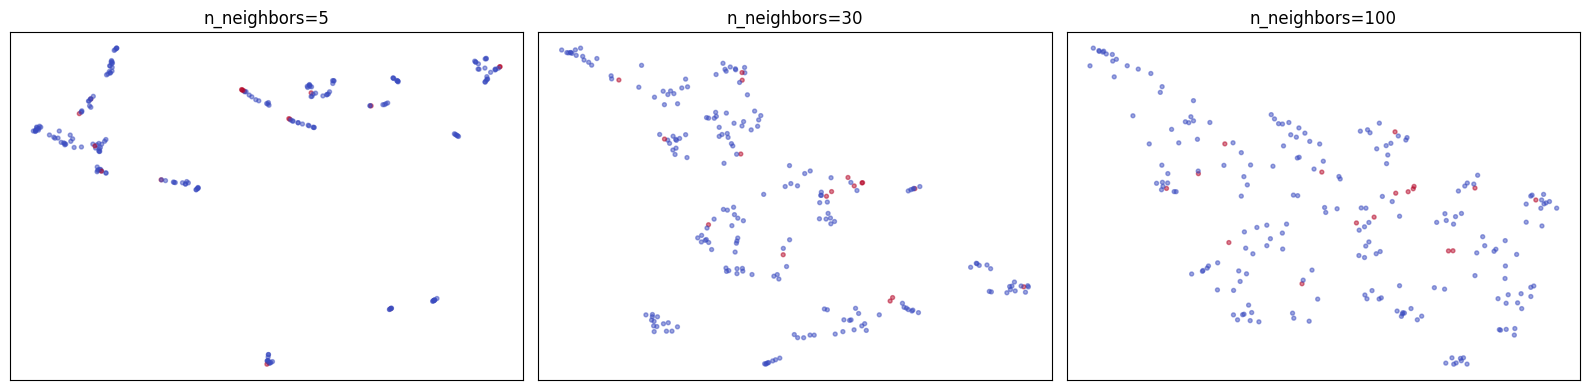

In [22]:
# --- Experiment: effect of n_neighbors ---
neighbors = [5, 30, 100]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, nn in zip(axes, neighbors):
    reducer = umap.UMAP(n_neighbors=nn, random_state=42)
    X_emb = reducer.fit_transform(X_sample)
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=target_sample, cmap='coolwarm', alpha=0.5, s=8)
    ax.set_title(f'n_neighbors={nn}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show();

/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


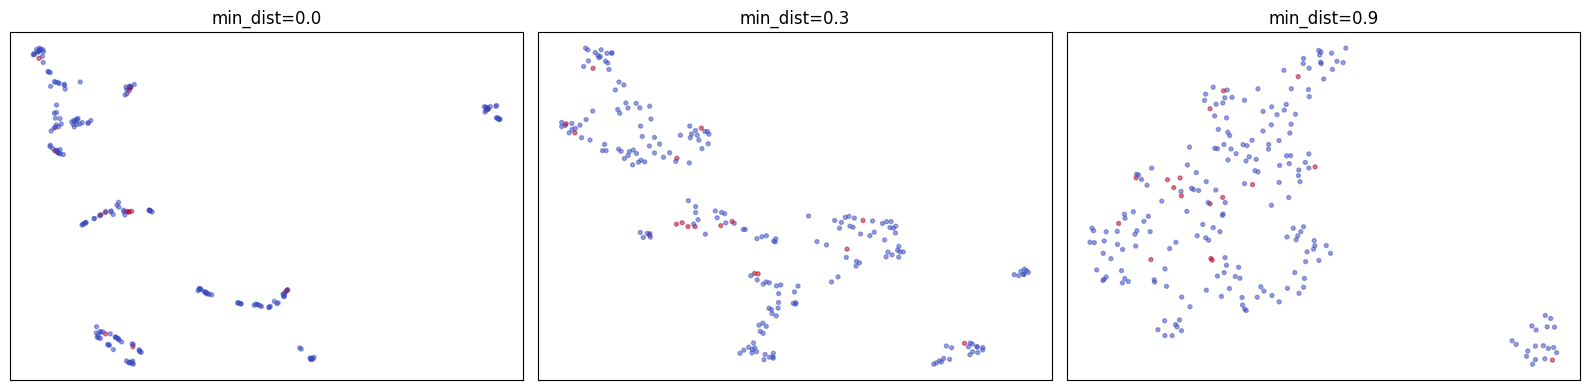

min_dist=0: points pack tightly, revealing fine local structure.
min_dist=0.9: points spread out evenly, showing global layout.
Default 0.1 is a good balance.


In [23]:
# --- Experiment: effect of min_dist ---
min_dists = [0.0, 0.3, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, md_val in zip(axes, min_dists):
    reducer = umap.UMAP(min_dist=md_val, random_state=42)
    X_emb = reducer.fit_transform(X_sample)
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=target_sample, cmap='coolwarm', alpha=0.5, s=8)
    ax.set_title(f'min_dist={md_val}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show();

print('min_dist=0: points pack tightly, revealing fine local structure.')
print('min_dist=0.9: points spread out evenly, showing global layout.')
print('Default 0.1 is a good balance.')

/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


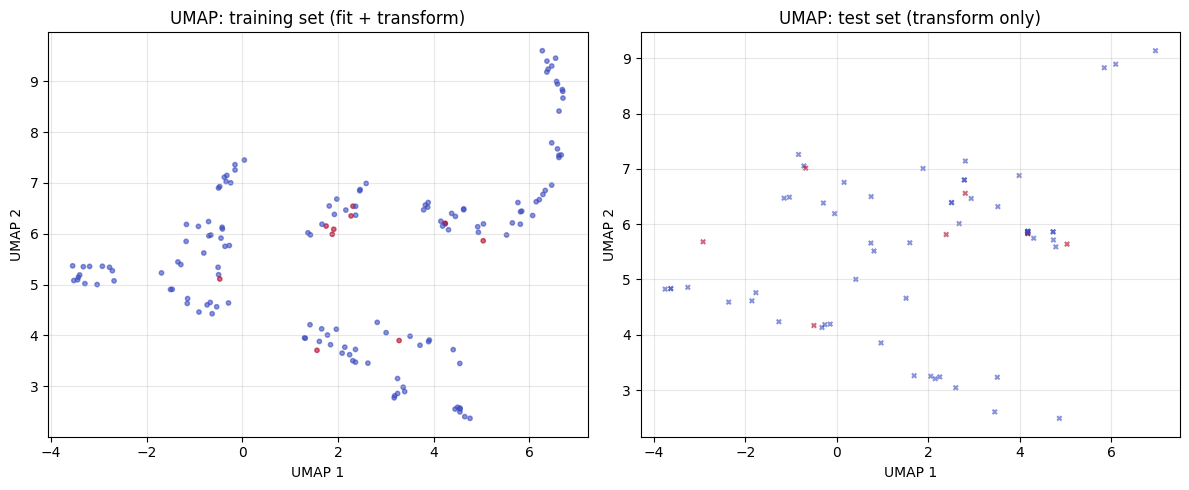

Test points map into SAME embedding space as training points.
Impossible with t-SNE. UMAP enables real-time monitoring of new data.


In [24]:
# --- UMAP's superpower: transform NEW data ---
# Split data into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, target_sample, test_size=0.3, random_state=42
)

# Fit UMAP on training set
reducer = umap.UMAP(random_state=42)
embedding_train = reducer.fit_transform(X_train)

# Transform test set into SAME embedding space
embedding_test = reducer.transform(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(
    embedding_train[:, 0], embedding_train[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.6, s=10, label='Train'
)
ax1.set_title('UMAP: training set (fit + transform)')

ax2.scatter(
    embedding_test[:, 0], embedding_test[:, 1],
    c=y_test, cmap='coolwarm', alpha=0.6, s=10, marker='x', label='Test'
)
ax2.set_title('UMAP: test set (transform only)')

for ax in [ax1, ax2]:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Test points map into SAME embedding space as training points.')
print('Impossible with t-SNE. UMAP enables real-time monitoring of new data.')

In [25]:
# --- UMAP as preprocessing for downstream models ---
# Reduce to 5 dimensions, then use in a classifier
reducer_5d = umap.UMAP(n_components=5, random_state=42)
X_umap_5d = reducer_5d.fit_transform(X_train)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Classifier on UMAP-reduced features
clf = RandomForestClassifier(random_state=42)
clf.fit(X_umap_5d, y_train)

# Transform test set
X_test_5d = reducer_5d.transform(X_test)
y_pred = clf.predict(X_test_5d)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy using 5 UMAP features: {acc:.2%}')
print(f'Original features: {X_train.shape[1]} -> 5 UMAP components')

/Users/mubojiao/miniforge3/envs/venv310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Accuracy using 5 UMAP features: 89.39%
Original features: 19 -> 5 UMAP components


### UMAP vs t-SNE visual differences:
| Feature | t-SNE | UMAP |
|---------|-------|------|
| Cluster packing | Very tight (repulsion forces) | Moderate (balance of attraction/repulsion) |
| Empty space | Large gaps between clusters | Tighter overall packing |
| Global layout | Unreliable cluster positions | Cluster positions are meaningful |
| Outliers | Flung to edges | Placed near similar points |

### Parameter tuning guide:
- **Low n_neighbors (5-10)**: Fine detail, many small clusters
- **High n_neighbors (50-100)**: Coarse structure, big picture
- **Low min_dist (0.0-0.1)**: Tight clusters, focus on local density
- **High min_dist (0.5-0.9)**: Spread out, focus on global arrangement

## Dimensionality Reduction: Complete Summary

| Method | Type | Speed | Global | Local | `transform()` | Best For |
|--------|------|-------|--------|-------|---------------|----------|
| **GroupBy** | Row reduction | Fast | - | - | N/A | Summaries, aggregation |
| **PCA** | Linear feature | Fastest | Yes | No | Yes | Baseline, preprocessing, interpretation |
| **t-SNE** | Non-linear feature | Slow | No | Yes | No | Classic visualization, fine clusters |
| **UMAP** | Non-linear feature | Fast | Yes | Yes | **Yes** | Modern viz, preprocessing, new data |

### Practical workflow for any dataset:
```
1. PCA → quick look, check variance, denoise
2. UMAP → detailed exploration, discover clusters
3. t-SNE → confirm clusters with classic method
4. Transform new data → UMAP only
```

<div class="alert alert-success">
<strong>Key insight</strong>: These are complementary tools. Start with PCA, dive deeper with UMAP, validate with t-SNE.
</div>